## **SHOR'S ALGORITHM**

In [12]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction
from math import floor, gcd, log
from sympy import isprime

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit.transpiler import CouplingMap, generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [13]:
primes = [n for n in range (2, 100) if isprime(n)]
semiprimes = [p * q for p in primes for q in primes if p != q and p * q <= 4757]

N = 15 #random.choice(semiprimes)
a = 2 #random.randint(2, N-1)

print(f"N = {N}\na = {a}")

N = 15
a = 2


In [17]:
#menghitung gcd
faktor = gcd(a, N)

if faktor != 1: #kalau bukan bilangan prima
    q = faktor
    p = N//q
    print(f"a dan N tidak co-prime!")
    print(f"Faktor → p={p}, q={q}, N={p}×{q}={N}")

else: #kalau bilangan prima, lanjut mencari orde
    q = None
    p = None
    L = int(np.ceil(np.log2(N)))
    qubit = L+3
    kmax = int(np.log2(2 * qubit))
    shots = 1024
    print(f"a dan N co-prime, lanjut ke quantum circuit...")
    print(f"L = {L}\nqubit = {qubit}\nkmax = {kmax}")

    qc = QuantumCircuit(qubit)
    #optimisasi 3: approximate qft
    def approx_qft(n, kmax):
        qc = QuantumCircuit(n, name='aQFT')
        for i in range(n-1, -1, -1):
            qc.h(i)
            for j in range(i - 1, -1, -1):
                if (i-j) <= kmax:
                    k = i - j 
                    theta = np.pi / (2**k)
                    qc.cp(theta, i, j)
        return qc.to_gate()

    def approx_iqft(n, kmax):
        qc = QuantumCircuit(n, name = 'aIQFT')
        for i in range(n):
            for j in range(i - 1, -1, -1):
                if (i - j) <= kmax:
                    k = i - j
                    theta = -np.pi / (2**k)
                    qc.cp(theta, i, j)
            qc.h(i)
        return qc.to_gate()
    qc.barrier()
    
    #optimisasi 1: qft adder drapper
    def draper_add(n, val, kmax, inverse=False):
        name = 'DAdd†' if inverse else 'DAdd'
        arah_rotasi = -1 if inverse else 1
        qc = QuantumCircuit(n, name=name)
        for i in range(n):
            for j in range(i + 1):
                if (i - j) <= kmax and  (val >> j) & 1:
                    k = i - j
                    theta = arah_rotasi * (2**k)
                    qc.p(theta, i)
        return qc.to_gate()

    def controlled_mod_add(n, val, N_val, kmax):
        qc = QuantumCircuit(n+2, name = 'cModAdd')

        ctrl_q = n          #indeks ctrl
        anc_q = n+1         #indeks ancilla
        work_q = list(range(n))
        
        #masuk ke domain fourier
        qc.append(approx_qft(n, kmax), work_q)

        #nambah controlled
        for i in range(n):
            for j in range(i+1):
                if (i-j) <= kmax and (val >> j) & 1:
                    k = i - j
                    theta = np.pi / (2**k)
                    qc.cp(theta, ctrl_q, i)

        #mengurangi N untuk mendeteksi overflow
        qc.append(draper_add(n, N_val, kmax, inverse = True), work_q)
        qc.append(approx_iqft(n, kmax), work_q)
        qc.cx(n-1, anc_q)

        #balik ke domain fourier
        qc.append(approx_qft(n, kmax), work_q)

        #jika overflow, menambahkan N lagi
        for i in range(n):
            for j in range(i+1):
                if (i-j) <= kmax and (N_val>>j) & 1:
                    k = i - j
                    theta = np.pi / (2**k)
                    qc.cp(theta, anc_q, i)

        #keluar dari domain fourier
        qc.append(approx_iqft(n, kmax), work_q)
        return qc.to_gate()

    qc.barrier()

    def  modular_exp_gate(a, power, N, n_qubits):
        dim = 2 ** n_qubits
        U = np.zeros((dim,dim))

        for y in range(dim):
            if y < N:
                fy = pow((a, power, N)*y) % N
            else:
                fy = y
            U[fy][y] = 1.0

        return UnitaeryGate(U, label=f'U^{power}')

    #optimisasi 2: semi-classical qft
    def qpe(circuit, ctrl, work, ancilla, target, cbits, a, N, L, n, kmax):
        circuit.x(target[0])

        for i in range(2 * L - 1, -1, -1):
            circuit.h(ctrl[0])

            u_gate  = modular_exp_gate(a, 2 ** i, N, L)
            c_ugate = u_gate.control(1)
            qubits  = [ctrl[0]] + list(target)
            circuit.append(c_ugate, qubits)

        for k in range(i + 1, 2 * L):
            theta = -math.pi / (2 ** (k - i))
            with circuit.if_test((cbits[k], 1)):
                circuit.p(theta, ctrl[0])

        circuit.h(ctrl[0])
        circuit.measure(ctrl[0], cbits[i])
        circuit.reset(ctrl[0])

    qc.barrier()

    #mencari orde r
    def find_orde(counts, a, N, L):
        factor_found = []
        for state, count in counts.items():
            x = int(state, 2)
            if x == 0:
                continue

            frac = Fraction(x, 2**(2*L)).limit_denominator(N)
            r =  frac.denominator

            if r % 2 != 0:
                continue

            c1 = gcd (pow(a, r//2)- 1, N)
            c2 = gcd(pow(a, r//2) + 1, N)

            for c in [c1, c2]:
                if 1<c<N and N%c == 0:
                    factor_found.append((c, N//c))

        return factor_found

a dan N co-prime, lanjut ke quantum circuit...
L = 4
qubit = 7
kmax = 3


In [18]:
# total qubit = 1 + L = L+1 (lebih simpel karena pakai unitary)
ctrl   = QuantumRegister(1,    'ctrl')
target = QuantumRegister(L,    'target')
cbits  = ClassicalRegister(2*L, 'cbits')

qc = QuantumCircuit(ctrl, target, cbits)

print(f'Struktur Register:')
print(f'  ctrl   = 1 qubit')
print(f'  target = {L} qubit')
print(f'  total  = {1+L} qubit')

# qpe baru tidak butuh work, ancilla, n, kmax
qpe(qc, ctrl, None, None, target, cbits, a, N, L, None, None)

qc.draw('mpl', fold=40)

Struktur Register:
  ctrl   = 1 qubit
  target = 4 qubit
  total  = 5 qubit


TypeError: pow() missing required argument 'exp' (pos 2)

In [ ]:
simulator = AerSimulator()
qc_transpiled = transpile(qc, simulator)
job       = simulator.run(qc_transpiled, shots=shots)
result    = job.result()
counts    = result.get_counts()

print(f'Simulasi selesai!')
print(f'Total shots = {shots}')
print(f'Total states terukur = {len(counts)}')
print(f'\nTop 10 hasil pengukuran:')
top10 = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:10]
for state, count in top10:
    x = int(state, 2)
    print(f'  state={state} (x={x:5d}), count={count:4d}, prob={count/shots:.4f}')

Simulasi selesai!
Total shots = 1024
Total states terukur = 214

Top 10 hasil pengukuran:
  state=00000000 (x=    0), count=  74, prob=0.0723
  state=00000010 (x=    2), count=  57, prob=0.0557
  state=00000011 (x=    3), count=  51, prob=0.0498
  state=00000001 (x=    1), count=  27, prob=0.0264
  state=11010100 (x=  212), count=  16, prob=0.0156
  state=11101100 (x=  236), count=  15, prob=0.0146
  state=11111101 (x=  253), count=  15, prob=0.0146
  state=10101000 (x=  168), count=  14, prob=0.0137
  state=10101011 (x=  171), count=  14, prob=0.0137
  state=10100111 (x=  167), count=  14, prob=0.0137


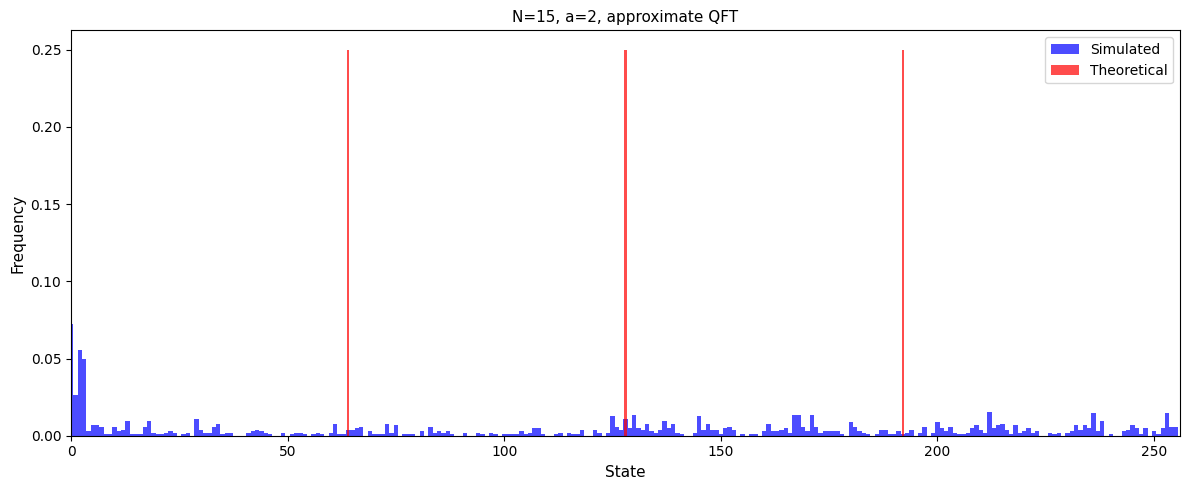

r teoritis = 4


In [ ]:
def theoretical_distribution(N, a, L):
    r = 1
    while pow(a, r, N) != 1 and r < N:
        r += 1
    total_states = 2 ** (2 * L)
    theo = {}
    for s in range(r):
        x = round(s * total_states / r)
        theo[x] = theo.get(x, 0) + (1 / r)
    return theo, r

theo_dist, r_theo = theoretical_distribution(N, a, L)
total_states      = 2 ** (2 * L)

all_x  = list(range(total_states))
sim_y  = [counts.get(format(x, f'0{2*L}b'), 0) / shots for x in all_x]
theo_y = [theo_dist.get(x, 0) for x in all_x]

fig, ax = plt.subplots(figsize=(12, 5))

# plot seperti paper: bar tipis overlap
ax.bar(all_x, sim_y,  color='blue', alpha=0.7, width=1.0, label='Simulated')
ax.bar(all_x, theo_y, color='red',  alpha=0.7, width=0.5, label='Theoretical')

ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(f'N={N}, a={a}, approximate QFT', fontsize=11)
ax.legend(fontsize=10)
ax.set_xlim(0, total_states)

plt.tight_layout()
plt.savefig('probability_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'r teoritis = {r_theo}')

In [ ]:
print(f'r teoritis = {r_theo}')
print(f'Puncak teoritis seharusnya di:')
for s in range(r_theo):
    x = round(s * total_states / r_theo)
    print(f'  s={s} → state={x}')

print(f'\nTop 5 state hasil simulasi:')
top5 = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:5]
for state, count in top5:
    print(f'  state={int(state,2)}, count={count}')

r teoritis = 4
Puncak teoritis seharusnya di:
  s=0 → state=0
  s=1 → state=64
  s=2 → state=128
  s=3 → state=192

Top 5 state hasil simulasi:
  state=0, count=74
  state=2, count=57
  state=3, count=51
  state=1, count=27
  state=212, count=16
